# Offshore Wind-to-Hydrogen Process Simulation

This notebook demonstrates a complete offshore wind-to-hydrogen value chain using NeqSim:

1. **Wind Farm** — Power generation from offshore wind turbines with power curves and AEP
2. **Subsea Power Cable** — AC/HVDC cable sizing with losses and ampacity
3. **Electrolyzer** — PEM/alkaline water electrolysis producing H2 and O2
4. **H2 Compression** — Compression to pipeline transport pressure
5. **H2 Pipeline Design** — Wall thickness per ASME B31.12 with embrittlement derating
6. **Ammonia Synthesis** — Haber-Bosch reactor for green ammonia production

All calculations use NeqSim Java classes via the `jneqsim` gateway.

In [1]:
# NeqSim setup - dual-boot (devtools for local dev, pip for Colab)
import importlib, subprocess, sys

try:
    from neqsim_dev_setup import neqsim_init, neqsim_classes
    ns = neqsim_init(recompile=False)
    ns = neqsim_classes(ns)
    NEQSIM_MODE = "devtools"
    print("NeqSim loaded via devtools (local dev mode)")
except ImportError:
    try:
        import neqsim
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "neqsim"])
    from neqsim import jneqsim
    NEQSIM_MODE = "pip"
    print("NeqSim loaded via pip package")

Classpath:
  1. C:\Users\ESOL\Documents\GitHub\neqsim\target\classes
  2. C:\Users\ESOL\Documents\GitHub\neqsim\src\main\resources
  3. C:\Users\ESOL\Documents\GitHub\neqsim\target\neqsim-3.6.0.jar

JVM started: C:\Users\ESOL\graalvm\graalvm-jdk-25.0.1+8.1\bin\server\jvm.dll
Ready — call neqsim_classes(ns) to import classes
All NeqSim classes imported OK
NeqSim loaded via devtools (local dev mode)


In [3]:
# Import required classes
import numpy as np
import matplotlib.pyplot as plt
import jpype

if NEQSIM_MODE == "devtools":
    WindFarm = jpype.JClass("neqsim.process.equipment.powergeneration.WindFarm")
    SubseaPowerCable = jpype.JClass("neqsim.process.equipment.subsea.SubseaPowerCable")
    Electrolyzer = jpype.JClass("neqsim.process.equipment.electrolyzer.Electrolyzer")
    Compressor = jpype.JClass("neqsim.process.equipment.compressor.Compressor")
    Stream = jpype.JClass("neqsim.process.equipment.stream.Stream")
    ProcessSystem = jpype.JClass("neqsim.process.processmodel.ProcessSystem")
    SystemSrkEos = jpype.JClass("neqsim.thermo.system.SystemSrkEos")
    Fluid = jpype.JClass("neqsim.thermo.Fluid")
    AmmoniaSynthesisReactor = jpype.JClass("neqsim.process.equipment.reactor.AmmoniaSynthesisReactor")
    HydrogenPipelineDesign = jpype.JClass("neqsim.process.mechanicaldesign.pipeline.HydrogenPipelineDesign")
else:
    from neqsim import jneqsim
    WindFarm = jneqsim.process.equipment.powergeneration.WindFarm
    SubseaPowerCable = jneqsim.process.equipment.subsea.SubseaPowerCable
    Electrolyzer = jneqsim.process.equipment.electrolyzer.Electrolyzer
    Compressor = jneqsim.process.equipment.compressor.Compressor
    Stream = jneqsim.process.equipment.stream.Stream
    ProcessSystem = jneqsim.process.processmodel.ProcessSystem
    SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
    Fluid = jneqsim.thermo.Fluid
    AmmoniaSynthesisReactor = jneqsim.process.equipment.reactor.AmmoniaSynthesisReactor
    HydrogenPipelineDesign = jneqsim.process.mechanicaldesign.pipeline.HydrogenPipelineDesign

print("All classes imported successfully")

All classes imported successfully


## 1. Wind Farm Configuration

We model a 1.5 GW offshore wind farm (100 × 15 MW turbines) similar to Dogger Bank.
The turbines use a standard cubic power curve with cut-in, rated, and cut-out speeds.

In [4]:
# Create wind farm
farm = WindFarm("North Sea Wind Farm", 100)
farm.setRatedPowerPerTurbine(15.0e6)  # 15 MW per turbine
farm.setRotorDiameter(236.0)          # meters
farm.setHubHeight(135.0)              # meters

# Power curve parameters
farm.setCutInSpeed(3.0)    # m/s
farm.setRatedSpeed(12.0)   # m/s
farm.setCutOutSpeed(25.0)  # m/s

# Environmental corrections
farm.setAirTemperature(10.0)              # 10 deg C (North Sea average)
farm.setAtmosphericPressure(101325.0)     # Pa
farm.setWakeLossFactor(0.10)              # 10% wake losses
farm.setAvailabilityFactor(0.95)          # 95% availability
farm.setElectricalLossFactor(0.02)        # 2% electrical losses

# Weibull distribution for AEP (typical North Sea)
farm.setWeibullShape(2.1)
farm.setWeibullScale(10.5)  # m/s mean

print(f"Wind Farm: {farm.getName()}")
print(f"Total rated capacity: {farm.getTotalRatedPower() / 1e6:.0f} MW")
print(f"Number of turbines: {farm.getNumberOfTurbines()}")
print(f"Rotor area per turbine: {farm.getRotorArea():.0f} m2")

Wind Farm: North Sea Wind Farm
Total rated capacity: 1500 MW
Number of turbines: 100
Rotor area per turbine: 43744 m2


## 2. Wind Turbine Power Curve

Plot the power output as a function of wind speed for a single turbine.

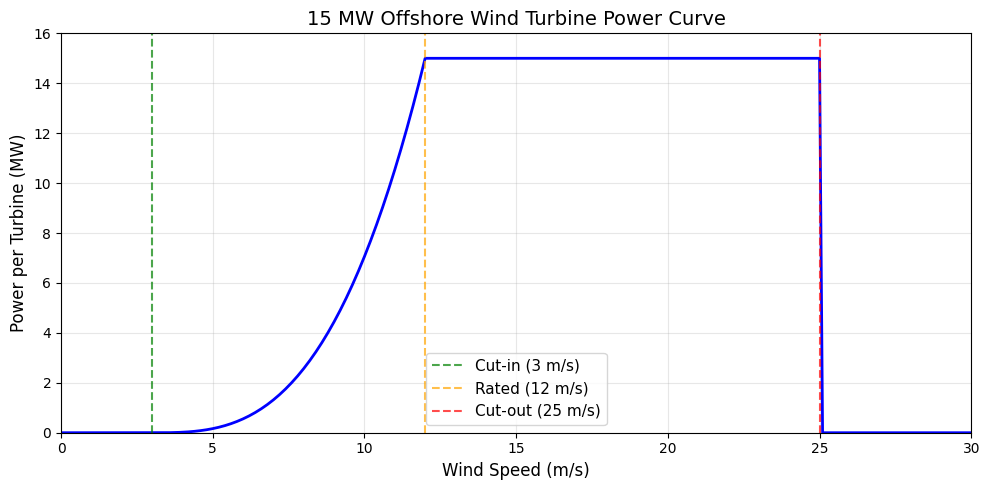

In [5]:
# Generate power curve
wind_speeds = np.linspace(0, 30, 301)
power_curve = np.array([farm.calculateTurbinePower(float(v)) / 1e6 for v in wind_speeds])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(wind_speeds, power_curve, 'b-', linewidth=2)
ax.axvline(x=3.0, color='g', linestyle='--', alpha=0.7, label='Cut-in (3 m/s)')
ax.axvline(x=12.0, color='orange', linestyle='--', alpha=0.7, label='Rated (12 m/s)')
ax.axvline(x=25.0, color='r', linestyle='--', alpha=0.7, label='Cut-out (25 m/s)')
ax.set_xlabel('Wind Speed (m/s)', fontsize=12)
ax.set_ylabel('Power per Turbine (MW)', fontsize=12)
ax.set_title('15 MW Offshore Wind Turbine Power Curve', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 30)
ax.set_ylim(0, 16)
plt.tight_layout()
plt.show()

## 3. Annual Energy Production (AEP)

Calculate AEP using Weibull wind speed probability distribution.

In [6]:
# Calculate AEP
aep_wh = farm.calculateAEP()
aep_gwh = aep_wh / 1e9
capacity_factor_est = aep_wh / (farm.getTotalRatedPower() * 8760) * 100

print(f"Annual Energy Production: {aep_gwh:.1f} GWh")
print(f"Estimated capacity factor: {capacity_factor_est:.1f}%")
print(f"Equivalent full-load hours: {aep_wh / farm.getTotalRatedPower():.0f} h/yr")

Annual Energy Production: 4731.1 GWh
Estimated capacity factor: 36.0%
Equivalent full-load hours: 3154 h/yr


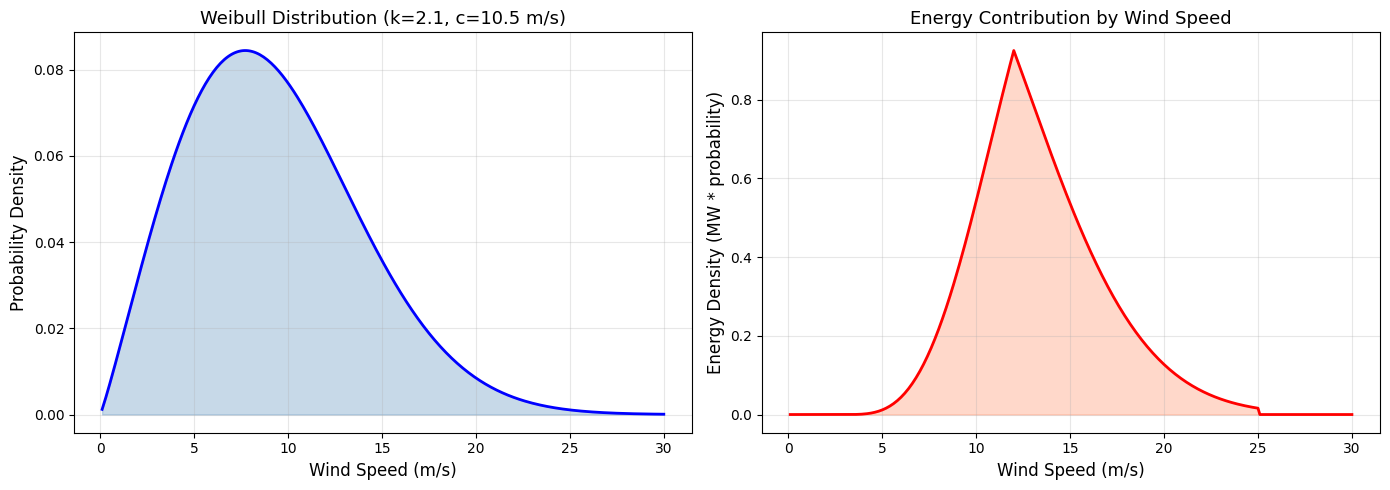

In [7]:
# Weibull distribution and power-weighted energy curve
from scipy.stats import weibull_min

k = farm.getWeibullShape()
c = farm.getWeibullScale()
ws = np.linspace(0.1, 30, 300)
weibull_pdf = weibull_min.pdf(ws, k, scale=c)
energy_density = np.array([farm.calculateTurbinePower(float(v)) for v in ws]) * weibull_pdf

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Weibull PDF
ax1.fill_between(ws, weibull_pdf, alpha=0.3, color='steelblue')
ax1.plot(ws, weibull_pdf, 'b-', linewidth=2)
ax1.set_xlabel('Wind Speed (m/s)', fontsize=12)
ax1.set_ylabel('Probability Density', fontsize=12)
ax1.set_title(f'Weibull Distribution (k={k:.1f}, c={c:.1f} m/s)', fontsize=13)
ax1.grid(True, alpha=0.3)

# Energy density (power * probability)
ax2.fill_between(ws, energy_density / 1e6, alpha=0.3, color='coral')
ax2.plot(ws, energy_density / 1e6, 'r-', linewidth=2)
ax2.set_xlabel('Wind Speed (m/s)', fontsize=12)
ax2.set_ylabel('Energy Density (MW * probability)', fontsize=12)
ax2.set_title('Energy Contribution by Wind Speed', fontsize=13)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Subsea Power Cable Design

Design a subsea HVAC export cable to transmit wind farm power to an offshore platform
or onshore substation. We use the IEC 60287 thermal model for ampacity and losses.

In [9]:
# Create and configure subsea power cable
CableType = SubseaPowerCable.CableType

cable = SubseaPowerCable("Export Cable")
cable.setCableType(CableType.XLPE_AC)
cable.setVoltage(220.0)            # kV (AC)
cable.setLength(80.0)              # km to shore
cable.setPowerRating(500.0)        # MW per cable
cable.setConductorArea(1200.0)     # mm2 copper
cable.setSeawaterTemperature(8.0)  # deg C
cable.setNumberOfCables(3)         # 3 cables for 1.5 GW
cable.setWaterDepth(30.0)          # m
cable.setBurialDepth(1.5)          # m burial
cable.run()

print("=== Subsea Power Cable Design ===")
print(f"Cable type: XLPE AC")
print(f"Voltage: {cable.getVoltage():.0f} kV")
print(f"Length: {cable.getLength():.0f} km")
print(f"Number of cables: 3")
print(f"Power per cable: {cable.getPowerRating():.0f} MW")
print(f"---")
print(f"Ampacity: {cable.getAmpacity():.0f} A")
print(f"Operating current: {cable.getOperatingCurrent():.0f} A")
print(f"Total power loss: {cable.getTotalPowerLoss():.2f} MW")
print(f"  Resistive loss: {cable.getResistiveLoss():.2f} MW")
print(f"  Dielectric loss: {cable.getDielectricLoss():.2f} MW")
print(f"Voltage drop: {cable.getVoltageDrop():.2f}%")
print(f"Reactive power: {cable.getReactivePower():.1f} MVAr")
print(f"Efficiency: {cable.getEfficiency() * 100:.2f}%")
print(f"Estimated cable cost: {cable.getCableCost():.1f} MUSD")

=== Subsea Power Cable Design ===
Cable type: XLPE AC
Voltage: 220 kV
Length: 80 km
Number of cables: 3
Power per cable: 500 MW
---
Ampacity: 988 A
Operating current: 460 A
Total power loss: 5.04 MW
  Resistive loss: 2.85 MW
  Dielectric loss: 2.19 MW
Voltage drop: 0.95%
Reactive power: 2189.6 MVAr
Efficiency: 98.99%
Estimated cable cost: 336.0 MUSD


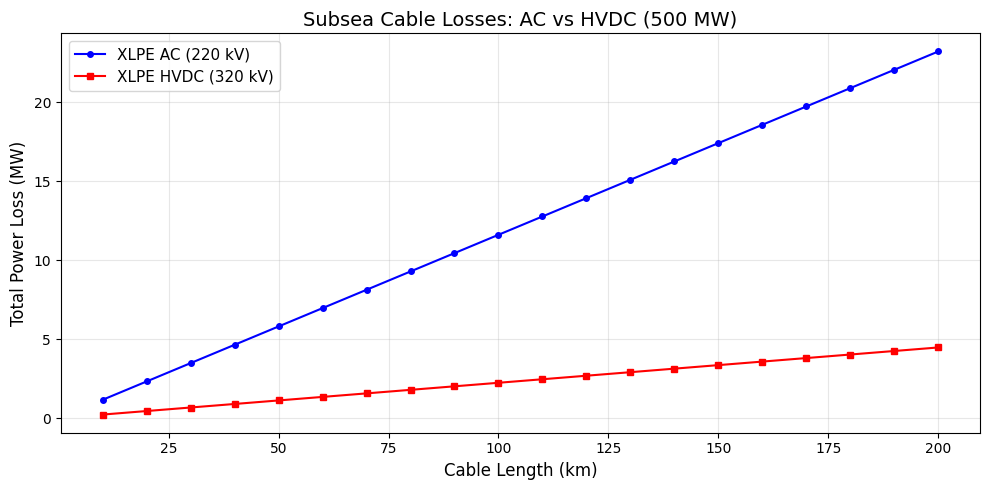

In [10]:
# Cable losses vs length comparison
lengths = np.arange(10, 201, 10)
ac_losses = []
dc_losses = []

for length in lengths:
    # AC cable
    c_ac = SubseaPowerCable("AC")
    c_ac.setCableType(CableType.XLPE_AC)
    c_ac.setVoltage(220.0)
    c_ac.setLength(float(length))
    c_ac.setPowerRating(500.0)
    c_ac.setConductorArea(1200.0)
    c_ac.setSeawaterTemperature(8.0)
    c_ac.run()
    ac_losses.append(c_ac.getTotalPowerLoss())

    # HVDC cable
    c_dc = SubseaPowerCable("DC")
    c_dc.setCableType(CableType.XLPE_HVDC)
    c_dc.setVoltage(320.0)
    c_dc.setLength(float(length))
    c_dc.setPowerRating(500.0)
    c_dc.setConductorArea(1200.0)
    c_dc.setSeawaterTemperature(8.0)
    c_dc.run()
    dc_losses.append(c_dc.getTotalPowerLoss())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(lengths, ac_losses, 'b-o', markersize=4, label='XLPE AC (220 kV)')
ax.plot(lengths, dc_losses, 'r-s', markersize=4, label='XLPE HVDC (320 kV)')
ax.set_xlabel('Cable Length (km)', fontsize=12)
ax.set_ylabel('Total Power Loss (MW)', fontsize=12)
ax.set_title('Subsea Cable Losses: AC vs HVDC (500 MW)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Water Electrolysis (Electrolyzer)

Convert wind power to hydrogen via PEM electrolysis.
The electrolyzer takes a water feed stream and produces H2 and O2 product streams.

In [11]:
# Create water feed for electrolyzer
water_fluid = Fluid().create2(
    ["water"],
    [1.0],
    "mole/sec"
)
water_feed = Stream("Water Feed", water_fluid)
water_feed.setTemperature(25.0, "C")
water_feed.setPressure(30.0, "bara")
water_feed.setFlowRate(500.0, "mole/sec")  # ~9 kg/s water
water_feed.run()

# Create electrolyzer
electrolyzer = Electrolyzer("PEM Electrolyzer", water_feed)
electrolyzer.run()

h2_stream = electrolyzer.getHydrogenOutStream()
o2_stream = electrolyzer.getOxygenOutStream()

h2_flow_mol_s = h2_stream.getFlowRate("mole/sec")
h2_flow_kg_hr = h2_flow_mol_s * 2.016e-3 * 3600  # MW H2 = 2.016 g/mol
o2_flow_mol_s = o2_stream.getFlowRate("mole/sec")

print("=== Electrolyzer Results ===")
print(f"Water feed: {water_feed.getFlowRate('mole/sec'):.1f} mol/s")
print(f"H2 production: {h2_flow_mol_s:.1f} mol/s ({h2_flow_kg_hr:.1f} kg/hr)")
print(f"O2 production: {o2_flow_mol_s:.1f} mol/s")
print(f"H2 pressure: {h2_stream.getPressure('bara'):.1f} bara")
print(f"H2 temperature: {h2_stream.getTemperature('C'):.1f} C")

=== Electrolyzer Results ===
Water feed: 500.0 mol/s
H2 production: 500.0 mol/s (3628.8 kg/hr)
O2 production: 250.0 mol/s
H2 pressure: 30.0 bara
H2 temperature: 25.0 C


## 6. Hydrogen Compression

Compress H2 from the electrolyzer outlet pressure (30 bara) to pipeline transport
pressure (200 bara) using a multi-stage compressor.

In [12]:
# Create H2 fluid for compression
h2_fluid = SystemSrkEos(273.15 + 25.0, 30.0)
h2_fluid.addComponent("hydrogen", 1.0)
h2_fluid.setMixingRule("classic")

h2_comp_feed = Stream("H2 Feed", h2_fluid)
h2_comp_feed.setFlowRate(h2_flow_kg_hr, "kg/hr")
h2_comp_feed.setTemperature(25.0, "C")
h2_comp_feed.setPressure(30.0, "bara")

# Two-stage compression: 30 -> 80 -> 200 bara
compressor1 = Compressor("H2 Compressor Stage 1", h2_comp_feed)
compressor1.setOutletPressure(80.0)
compressor1.setPolytropicEfficiency(0.75)

compressor2 = Compressor("H2 Compressor Stage 2", compressor1.getOutletStream())
compressor2.setOutletPressure(200.0)
compressor2.setPolytropicEfficiency(0.75)

# Build and run process
process = ProcessSystem()
process.add(h2_comp_feed)
process.add(compressor1)
process.add(compressor2)
process.run()

power1_kw = compressor1.getPower("kW")
power2_kw = compressor2.getPower("kW")
total_power_kw = power1_kw + power2_kw

print("=== H2 Compression ===")
print(f"Stage 1: {30:.0f} -> {compressor1.getOutletStream().getPressure('bara'):.0f} bara")
print(f"  Power: {power1_kw:.1f} kW")
print(f"  Outlet T: {compressor1.getOutletStream().getTemperature('C'):.1f} C")
print(f"Stage 2: {compressor1.getOutletStream().getPressure('bara'):.0f} -> {compressor2.getOutletStream().getPressure('bara'):.0f} bara")
print(f"  Power: {power2_kw:.1f} kW")
print(f"  Outlet T: {compressor2.getOutletStream().getTemperature('C'):.1f} C")
print(f"Total compression power: {total_power_kw:.1f} kW ({total_power_kw / 1e3:.2f} MW)")

=== H2 Compression ===
Stage 1: 30 -> 80 bara
  Power: 1441.1 kW
  Outlet T: 122.3 C
Stage 2: 80 -> 200 bara
  Power: 1818.3 kW
  Outlet T: 240.6 C
Total compression power: 3259.5 kW (3.26 MW)


## 7. Hydrogen Pipeline Mechanical Design

Design a subsea H2 pipeline per ASME B31.12 with hydrogen embrittlement derating.
This calculates required wall thickness, checks material compatibility, and
assesses hydrogen permeation rate.

In [13]:
# Create H2 pipeline mechanical design
h2_pipeline = HydrogenPipelineDesign(None)  # Standalone design (no process equipment)
h2_pipeline.setOuterDiameter(0.3238)        # 12.75" (12-inch pipe)
h2_pipeline.setDesignPressure(200.0)         # bara
h2_pipeline.setDesignTemperature(60.0)       # deg C
h2_pipeline.setMaterialGrade("X52")          # API 5L Grade
h2_pipeline.setHydrogenMoleFraction(1.0)     # Pure hydrogen
h2_pipeline.setDesignFactor(0.72)            # ASME B31.12 Class 1
h2_pipeline.setCorrosionAllowance(1.5)       # mm
h2_pipeline.setPipelineLength(100.0)         # km
h2_pipeline.setWaterDepth(30.0)              # m

# Run design calculation
h2_pipeline.calcDesign()

print("=== H2 Pipeline Design (ASME B31.12) ===")
print(f"Material: X52 (SMYS = {h2_pipeline.getSmys():.0f} MPa)")
print(f"Outer diameter: {h2_pipeline.getOuterDiameter() * 1000:.1f} mm")
print(f"Required wall thickness: {h2_pipeline.getRequiredWallThickness():.2f} mm")
print(f"H2 derating factor: {h2_pipeline.getHydrogenDeratingFactor():.3f}")
print(f"Material compatible: {h2_pipeline.isMaterialCompatible()}")
print(f"Permeation rate: {h2_pipeline.getPermeationRate():.2e} mol/(m*s)")
print(f"Design factor: {h2_pipeline.getDesignFactor():.2f}")

=== H2 Pipeline Design (ASME B31.12) ===
Material: X52 (SMYS = 358 MPa)
Outer diameter: 323.8 mm
Required wall thickness: 14.72 mm
H2 derating factor: 0.950
Material compatible: True
Permeation rate: 6.07e-06 mol/(m*s)
Design factor: 0.72


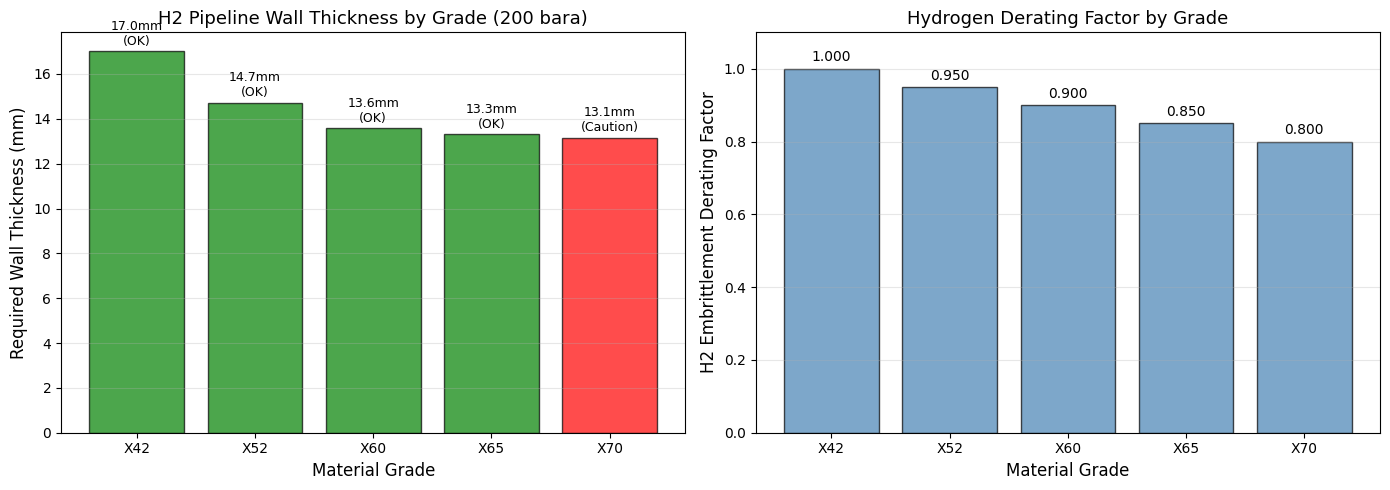

In [14]:
# Compare wall thickness for different material grades
grades = ["X42", "X52", "X60", "X65", "X70"]
wall_thicknesses = []
derating_factors = []
compatible = []

for grade in grades:
    design = HydrogenPipelineDesign(None)
    design.setOuterDiameter(0.3238)
    design.setDesignPressure(200.0)
    design.setDesignTemperature(60.0)
    design.setMaterialGrade(grade)
    design.setHydrogenMoleFraction(1.0)
    design.setDesignFactor(0.72)
    design.setCorrosionAllowance(1.5)
    design.calcDesign()
    wall_thicknesses.append(design.getRequiredWallThickness())
    derating_factors.append(design.getHydrogenDeratingFactor())
    compatible.append(design.isMaterialCompatible())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = ['green' if c else 'red' for c in compatible]
ax1.bar(grades, wall_thicknesses, color=colors, alpha=0.7, edgecolor='black')
ax1.set_xlabel('Material Grade', fontsize=12)
ax1.set_ylabel('Required Wall Thickness (mm)', fontsize=12)
ax1.set_title('H2 Pipeline Wall Thickness by Grade (200 bara)', fontsize=13)
ax1.grid(True, alpha=0.3, axis='y')
for i, (wt, comp) in enumerate(zip(wall_thicknesses, compatible)):
    label = 'OK' if comp else 'Caution'
    ax1.text(i, wt + 0.3, f'{wt:.1f}mm\n({label})', ha='center', fontsize=9)

ax2.bar(grades, derating_factors, color='steelblue', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Material Grade', fontsize=12)
ax2.set_ylabel('H2 Embrittlement Derating Factor', fontsize=12)
ax2.set_title('Hydrogen Derating Factor by Grade', fontsize=13)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim(0, 1.1)
for i, df in enumerate(derating_factors):
    ax2.text(i, df + 0.02, f'{df:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## 8. Ammonia Synthesis (Haber-Bosch)

Convert green hydrogen to ammonia using the Haber-Bosch process:

$$N_2 + 3H_2 \rightarrow 2NH_3 \quad \Delta H = -92.4 \text{ kJ/mol}$$

Typical conditions: 400-500°C, 150-300 bara, 15% per-pass conversion with recycle.

In [15]:
# Create synthesis gas feed (3:1 H2:N2 molar ratio)
syngas = SystemSrkEos(273.15 + 450.0, 200.0)
syngas.addComponent("hydrogen", 0.75)
syngas.addComponent("nitrogen", 0.25)
syngas.setMixingRule("classic")

syngas_feed = Stream("Syngas Feed", syngas)
syngas_feed.setFlowRate(10000.0, "kg/hr")
syngas_feed.setTemperature(450.0, "C")
syngas_feed.setPressure(200.0, "bara")
syngas_feed.run()

# Create ammonia synthesis reactor
reactor = AmmoniaSynthesisReactor("Haber-Bosch Reactor", syngas_feed)
reactor.setPerPassConversion(0.15)  # 15% per-pass
reactor.setIsothermal(False)        # Exothermic reaction
reactor.run()

print("=== Ammonia Synthesis Reactor ===")
print(f"Feed rate: {syngas_feed.getFlowRate('kg/hr'):.0f} kg/hr")
print(f"Feed temperature: {syngas_feed.getTemperature('C'):.0f} C")
print(f"Feed pressure: {syngas_feed.getPressure('bara'):.0f} bara")
print(f"---")
print(f"Per-pass conversion: {reactor.getConversion() * 100:.1f}%")
print(f"NH3 production rate: {reactor.getAmmoniaProductionRate('kg/hr'):.1f} kg/hr")
print(f"NH3 production rate: {reactor.getAmmoniaProductionRate('tonne/day'):.2f} tonne/day")
print(f"Heat duty: {reactor.getHeatDuty('MW'):.3f} MW")
print(f"Outlet temperature: {reactor.getOutletTemperature() - 273.15:.1f} C")

=== Ammonia Synthesis Reactor ===
Feed rate: 10000 kg/hr
Feed temperature: 450 C
Feed pressure: 200 bara
---
Per-pass conversion: 15.0%
NH3 production rate: 1499.9 kg/hr
NH3 production rate: 36.00 tonne/day
Heat duty: -1.130 MW
Outlet temperature: 561.3 C


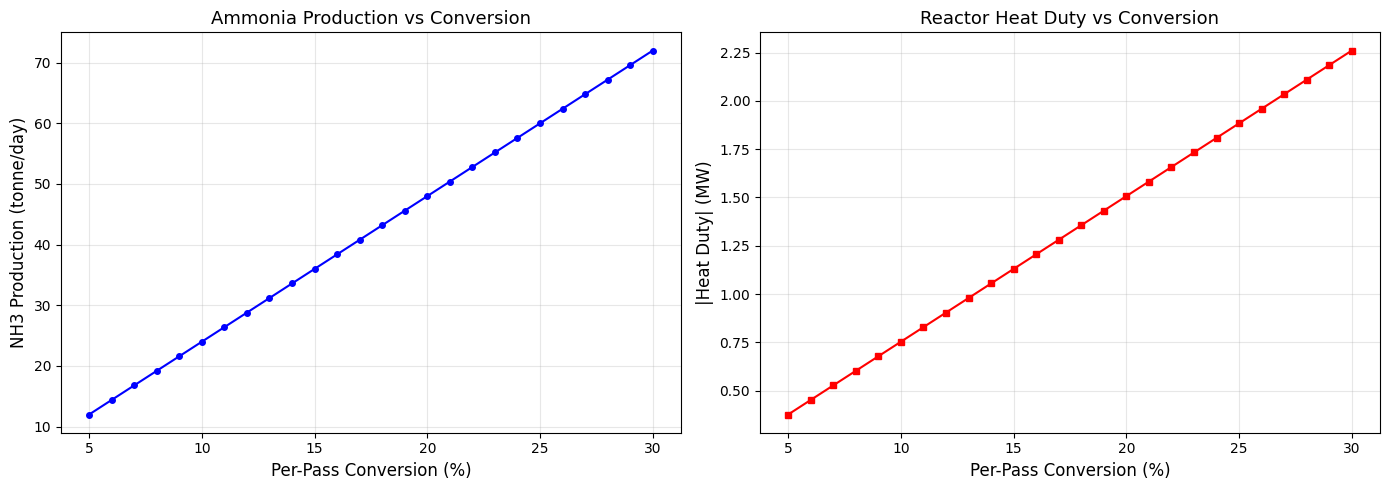

In [16]:
# Sensitivity: NH3 production vs per-pass conversion
conversions = np.linspace(0.05, 0.30, 26)
nh3_rates = []
heat_duties = []

for conv in conversions:
    syngas_s = SystemSrkEos(273.15 + 450.0, 200.0)
    syngas_s.addComponent("hydrogen", 0.75)
    syngas_s.addComponent("nitrogen", 0.25)
    syngas_s.setMixingRule("classic")
    feed_s = Stream("feed", syngas_s)
    feed_s.setFlowRate(10000.0, "kg/hr")
    feed_s.setTemperature(450.0, "C")
    feed_s.setPressure(200.0, "bara")
    feed_s.run()

    rx = AmmoniaSynthesisReactor("reactor", feed_s)
    rx.setPerPassConversion(float(conv))
    rx.setIsothermal(False)
    rx.run()
    nh3_rates.append(rx.getAmmoniaProductionRate("tonne/day"))
    heat_duties.append(abs(rx.getHeatDuty("MW")))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(conversions * 100, nh3_rates, 'b-o', markersize=4)
ax1.set_xlabel('Per-Pass Conversion (%)', fontsize=12)
ax1.set_ylabel('NH3 Production (tonne/day)', fontsize=12)
ax1.set_title('Ammonia Production vs Conversion', fontsize=13)
ax1.grid(True, alpha=0.3)

ax2.plot(conversions * 100, heat_duties, 'r-s', markersize=4)
ax2.set_xlabel('Per-Pass Conversion (%)', fontsize=12)
ax2.set_ylabel('|Heat Duty| (MW)', fontsize=12)
ax2.set_title('Reactor Heat Duty vs Conversion', fontsize=13)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Time-Series Wind Simulation

Run an hourly simulation with synthetic wind data to assess variable H2 production.

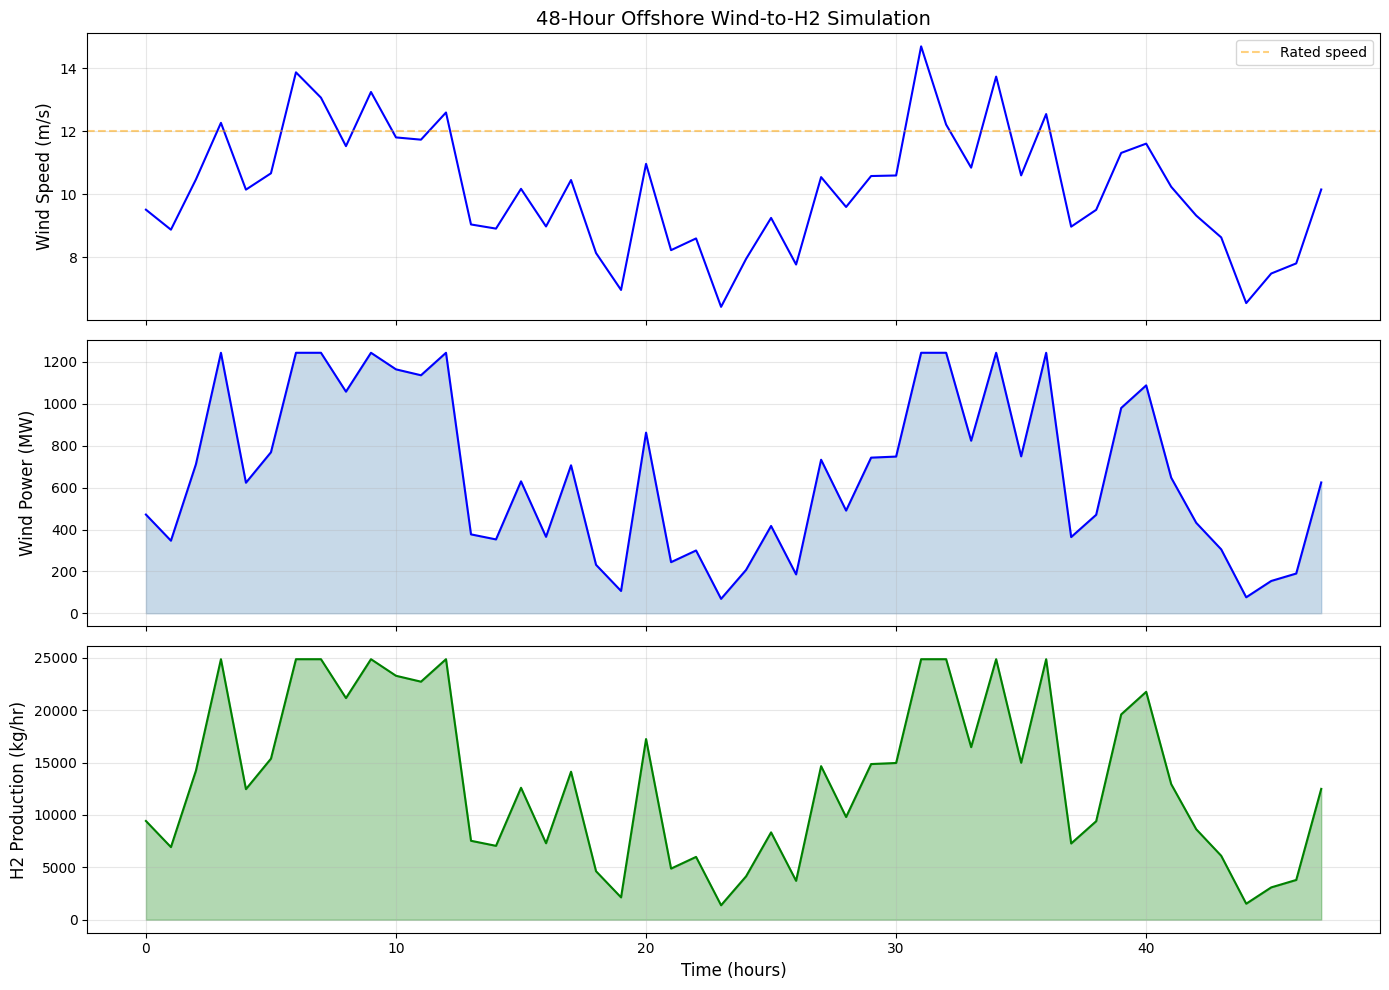

Average wind power: 670 MW
Total H2 produced (48h): 643091 kg
Average H2 production: 13398 kg/hr
Peak H2 production: 24880 kg/hr


In [17]:
# Generate 48-hour synthetic wind speed time series
np.random.seed(42)
hours = 48
t = np.arange(hours)

# Daily pattern + random fluctuations
mean_wind = 10.5
daily_cycle = 2.0 * np.sin(2 * np.pi * t / 24 - np.pi/3)
noise = np.random.normal(0, 1.5, hours)
wind_speeds_arr = np.clip(mean_wind + daily_cycle + noise, 0, 30)

# Run time series on wind farm
farm_ts = WindFarm("Time Series Farm", 100)
farm_ts.setRatedPowerPerTurbine(15.0e6)
farm_ts.setRotorDiameter(236.0)
farm_ts.setHubHeight(135.0)
farm_ts.setCutInSpeed(3.0)
farm_ts.setRatedSpeed(12.0)
farm_ts.setCutOutSpeed(25.0)
farm_ts.setWakeLossFactor(0.10)
farm_ts.setAvailabilityFactor(0.95)

# Convert to Java double array
import jpype
wind_java = jpype.JArray(jpype.JDouble)(len(wind_speeds_arr))
for i, v in enumerate(wind_speeds_arr):
    wind_java[i] = float(v)

farm_ts.setWindSpeedTimeSeries(wind_java)
farm_ts.runTimeSeries()

# Get power time series
power_ts_java = farm_ts.getPowerTimeSeries()
power_ts = np.array([power_ts_java[i] for i in range(len(power_ts_java))]) / 1e6  # MW

# Calculate H2 production per hour (assuming 50 kWh/kg H2 electrolyzer efficiency)
electrolyzer_efficiency = 50.0  # kWh/kg H2
h2_production = power_ts * 1000 / electrolyzer_efficiency  # kg/hr

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

ax1.plot(t, wind_speeds_arr, 'b-', linewidth=1.5)
ax1.axhline(y=12.0, color='orange', linestyle='--', alpha=0.5, label='Rated speed')
ax1.set_ylabel('Wind Speed (m/s)', fontsize=12)
ax1.set_title('48-Hour Offshore Wind-to-H2 Simulation', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.fill_between(t, power_ts, alpha=0.3, color='steelblue')
ax2.plot(t, power_ts, 'b-', linewidth=1.5)
ax2.set_ylabel('Wind Power (MW)', fontsize=12)
ax2.grid(True, alpha=0.3)

ax3.fill_between(t, h2_production, alpha=0.3, color='green')
ax3.plot(t, h2_production, 'g-', linewidth=1.5)
ax3.set_xlabel('Time (hours)', fontsize=12)
ax3.set_ylabel('H2 Production (kg/hr)', fontsize=12)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Average wind power: {np.mean(power_ts):.0f} MW")
print(f"Total H2 produced (48h): {np.sum(h2_production):.0f} kg")
print(f"Average H2 production: {np.mean(h2_production):.0f} kg/hr")
print(f"Peak H2 production: {np.max(h2_production):.0f} kg/hr")

## 10. Summary: Wind-to-Hydrogen Value Chain

Bringing all subsystems together into a complete overview.

In [18]:
# Summary table
print("=" * 70)
print("WIND-TO-HYDROGEN VALUE CHAIN SUMMARY")
print("=" * 70)
print(f"{'Component':<30} {'Parameter':<25} {'Value':>12}")
print("-" * 70)
print(f"{'Wind Farm':<30} {'Rated capacity':<25} {farm.getTotalRatedPower()/1e6:>10.0f} MW")
print(f"{'':30} {'AEP':<25} {aep_gwh:>10.0f} GWh")
print(f"{'':30} {'Capacity factor':<25} {capacity_factor_est:>10.1f} %")
print(f"{'Subsea Cable':<30} {'Total losses':<25} {cable.getTotalPowerLoss():>10.1f} MW")
print(f"{'':30} {'Efficiency':<25} {cable.getEfficiency()*100:>10.1f} %")
print(f"{'':30} {'Cost':<25} {cable.getCableCost():>10.0f} MUSD")
print(f"{'Electrolyzer':<30} {'H2 flow':<25} {h2_flow_kg_hr:>10.1f} kg/hr")
print(f"{'H2 Compression':<30} {'Power (2-stage)':<25} {total_power_kw:>10.0f} kW")
print(f"{'H2 Pipeline':<30} {'Wall thickness':<25} {h2_pipeline.getRequiredWallThickness():>10.1f} mm")
print(f"{'':30} {'H2 derating factor':<25} {h2_pipeline.getHydrogenDeratingFactor():>10.3f}")
print(f"{'NH3 Reactor':<30} {'Production':<25} {reactor.getAmmoniaProductionRate('tonne/day'):>10.2f} t/d")
print(f"{'':30} {'Heat duty':<25} {reactor.getHeatDuty('MW'):>10.3f} MW")
print("=" * 70)
print("\nAll calculations performed using NeqSim Java classes.")

WIND-TO-HYDROGEN VALUE CHAIN SUMMARY
Component                      Parameter                        Value
----------------------------------------------------------------------
Wind Farm                      Rated capacity                  1500 MW
                               AEP                             4731 GWh
                               Capacity factor                 36.0 %
Subsea Cable                   Total losses                     5.0 MW
                               Efficiency                      99.0 %
                               Cost                             336 MUSD
Electrolyzer                   H2 flow                       3628.8 kg/hr
H2 Compression                 Power (2-stage)                 3259 kW
H2 Pipeline                    Wall thickness                  14.7 mm
                               H2 derating factor             0.950
NH3 Reactor                    Production                     36.00 t/d
                               Heat dut